In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold0_-0.5_summary.tsv", sep="\t")
fold0["fold"] = [0 for i in range(len(fold0))]

In [3]:
fold1 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold1_-0.5_summary.tsv", sep="\t")
fold1["fold"] = [1 for i in range(len(fold1))]

In [4]:
fold2 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold2_-0.5_summary.tsv", sep="\t")
fold2["fold"] = [2 for i in range(len(fold2))]

In [5]:
df = pd.concat([fold0, fold1, fold2], ignore_index=True)

In [6]:
len(df)

164

In [7]:
df.head()

,chrom,start,end,fold,PearsonR,flat_start,flat_end,centered_start,centered_end,centered_flat_start,...,num_edits,GC_seq,GC_slice,GC_slice_edited,init_CTCFs_num,CTCFs_num,FIMO_sum,FIMO_max,orientation,positions
0,chr1,37793792,39104512,0,0.861165,195.0,323.0,37799936,39110656,192,...,885.0,0.439010,0.459961,0.524414,0,6,116.884754,23.597869,---+-+,"[(187, 206), (251, 270), (644, 663), (1661, 16..."
1,chr11,65921024,67231744,0,0.746112,76.0,199.0,65677312,66988032,195,...,547.0,0.423124,0.422852,0.460449,1,6,98.783829,25.030489,++-+-+,"[(223, 242), (289, 308), (357, 376), (480, 499..."
2,chr3,38414336,39725056,0,0.670098,198.0,422.0,38524928,39835648,144,...,604.0,0.404138,0.437988,0.449707,0,4,65.972716,22.499068,++++,"[(278, 297), (337, 356), (422, 441), (1932, 19..."
3,chr3,40978432,42289152,0,0.754782,82.0,182.0,40724480,42035200,206,...,686.0,0.416176,0.418945,0.403809,0,7,109.634081,23.450102,+++--++,"[(406, 425), (890, 909), (944, 963), (1187, 12..."
4,chr3,51795968,53106688,0,0.855747,247.0,416.0,51949568,53260288,172,...,799.0,0.439903,0.479492,0.542969,1,4,84.435493,25.464185,-+-+,"[(376, 395), (456, 475), (1234, 1253), (1309, ..."


In [8]:
df['optimization_successful'] = df['SCD'] > 50

In [9]:
df[df["SCD"] < 50]

,chrom,start,end,fold,PearsonR,flat_start,flat_end,centered_start,centered_end,centered_flat_start,...,GC_seq,GC_slice,GC_slice_edited,init_CTCFs_num,CTCFs_num,FIMO_sum,FIMO_max,orientation,positions,optimization_successful
18,chr4,95250432,96561152,0,0.828356,92.0,209.0,95033344,96344064,198,...,0.411942,0.364746,0.365723,0,0,0.0,0.0,no,(),False
73,chr1,185141248,186451968,1,0.887753,323.0,455.0,185413632,186724352,190,...,0.428371,0.377930,0.411621,0,0,0.0,0.0,no,(),False
106,chr11,39598080,40908800,2,0.791830,250.0,379.0,39716864,41027584,192,...,0.389825,0.356934,0.349609,0,0,0.0,0.0,no,(),False
129,chr16,83644416,84955136,2,0.737162,56.0,317.0,83501056,84811776,126,...,0.380978,0.393066,0.411621,0,0,0.0,0.0,no,(),False


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

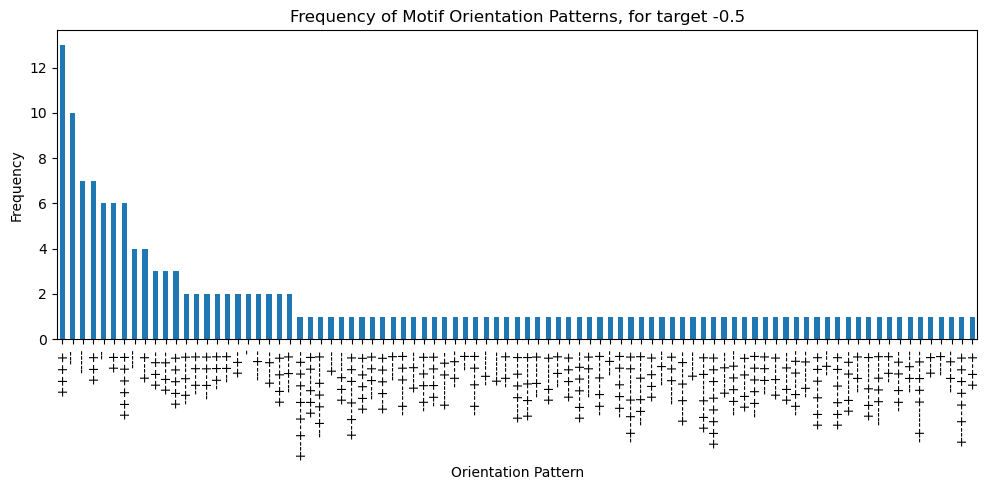

In [11]:
orientation_counts = df[df['orientation'] != "no"]['orientation'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
orientation_counts.plot(kind='bar')
plt.xlabel("Orientation Pattern")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns, for target -0.5")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
df_melted = df.melt(value_vars=['URQ_result', 'URQ_target'], var_name='Type', value_name='URQ mean')

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Type', y='URQ mean', data=df_melted)
plt.axhline(y=-0.5, color='red', linestyle='--', linewidth=1.5, label='target')
plt.xticks([0, 1], ['Before Optimization', 'After Optimization'])
plt.title('Boxplot of URQ mean before and after optimization')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df_box_melted = df.melt(value_vars=['init_CTCFs_num', 'CTCFs_num'],
                            var_name='num_ctcfs', value_name='CTCF Count')

# Rename the categories for clarity
label_map = {
    'init_CTCFs_num': 'Before Optimization',
    'CTCFs_num': 'After Optimization'
}
df_box_melted['num_ctcfs'] = df_box_melted['num_ctcfs'].map(label_map)

# Plotting
plt.figure(figsize=(6, 5))
sns.boxplot(x='num_ctcfs', y='CTCF Count', data=df_box_melted)
plt.title('CTCF Count Before and After Optimization')
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pearsonr

In [ ]:
# Calculate Pearson correlation coefficient
r_value, p_value = pearsonr(df['URQ_target'], df['URQ_result'])

In [ ]:
# Determine shared range for both axes
min_val = min(df['URQ_target'].min(), df['URQ_result'].min())
max_val = max(df['URQ_target'].max(), df['URQ_result'].max())

# Plotting the scatterplot with equal axis limits and square aspect ratio
plt.figure(figsize=(6, 6))
sns.scatterplot(x='URQ_target', y='URQ_result', data=df)
plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--')  # reference diagonal
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca().set_aspect('equal', adjustable='box')
plt.title(f'Pearson r = {r_value:.2f}')
plt.xlabel('target URQ mean')
plt.ylabel('result URQ mean')
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x='CTCFs_num', y='URQ_result', data=df)
plt.xlabel('CTCFs_num')
plt.ylabel('result URQ mean')
plt.title('Scatterplot of CTCFs_num vs result URQ mean')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_sum', y='URQ_result', data=df)
plt.xlabel('FIMO_sum')
plt.ylabel('result URQ mean')
plt.title(f'FIMO_sum vs URQ_result')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_max', y='URQ_result', data=df[df["SCD"] > 50])
plt.xlabel('FIMO_max')
plt.ylabel('result URQ mean')
plt.title(f'FIMO_max vs URQ_result')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='last_accepted_step_query',
    y='GC_seq',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('last step with accepted edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

In [ ]:
df.columns

In [ ]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='last_accepted_step_query',
    y='flat_GC_content',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('last step with accepted edits')
plt.ylabel('GC content of the flat region')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='num_edits',
    y='GC_seq',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)

plt.xlabel('number of edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='num_edits',
    y='flat_GC_content',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)

plt.xlabel('number of edits')
plt.ylabel('GC content of the flat region')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='URQ_result',
    y='GC_seq',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)

plt.xlabel('result URQ mean')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='last_accepted_step_query',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()


In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='last_accepted_step_query',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='last_accepted_step_query',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='num_edits',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('Number of Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='num_edits',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('Number of Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='num_edits',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('Number of Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
fold_map = {0: 'test', 1: 'valid', 2: 'train'}
df['set'] = df['fold'].map(fold_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='set', y='last_accepted_step_query', data=df, order=['train', 'valid', 'test'])
plt.xlabel('Fold')
plt.ylabel('Last Step with Accepted Edits')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='set', y='num_edits', data=df, order=['train', 'valid', 'test'])
plt.xlabel('Fold')
plt.ylabel('Number of Edits')
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import ttest_rel

In [ ]:
t_stat, p_val = ttest_rel(df['GC_slice'], df['GC_slice_edited'])

In [ ]:
t_stat, p_val

In [ ]:
# Melt the DataFrame for plotting
df_gc_melted = df.melt(value_vars=['GC_slice', 'GC_slice_edited'],
                          var_name='Stage', value_name='GC Content')

# Rename the stages for clarity
stage_map = {
    'GC_slice': 'Before Optimization',
    'GC_slice_edited': 'After Optimization'
}
df_gc_melted['Stage'] = df_gc_melted['Stage'].map(stage_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Stage', y='GC Content', data=df_gc_melted)
plt.title('GC Content of Sequence Slice\nBefore vs After Optimization')
plt.text(0.5, max(df_gc_melted['GC Content']) + 0.005,
         f'p = {p_val:.3g}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
df.columns